# Section 1: Setup + MLflow Tracking (Run this first)

In [1]:
import mlflow
import os

# Force allow file store inside Python
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# Set correct path
project_root = os.path.dirname(os.getcwd())
mlruns_path = os.path.join(project_root, "mlruns")

mlflow.set_tracking_uri(f"file:{mlruns_path}")
mlflow.set_experiment("ChurnGuard_Baseline")

print("✅ MLflow setup completed with file store!")
print("Tracking URI:", mlflow.get_tracking_uri())

✅ MLflow setup completed with file store!
Tracking URI: file:/Users/amritanshudash/Desktop/ChurnGuard/mlruns


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
import os
from mlflow.tracking import MlflowClient

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ====================== MLflow Setup ======================
project_root = os.path.dirname(os.getcwd())          # Go one level up from notebooks/
mlruns_path = os.path.join(project_root, "mlruns")

mlflow.set_tracking_uri(f"file:{mlruns_path}")
mlflow.set_experiment("ChurnGuard_Baseline")

print("✅ MLflow Tracking URI set successfully!")
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment: ChurnGuard_Baseline")

✅ MLflow Tracking URI set successfully!
Tracking URI: file:/Users/amritanshudash/Desktop/ChurnGuard/mlruns
Experiment: ChurnGuard_Baseline


# Section 2: Data Loading + EDA

In [3]:
# Load Data
df = pd.read_csv("churn_data.csv")

print("✅ Shape:", df.shape)
print("\n📋 Columns:", df.columns.tolist())

print("\n🔍 Basic Info:")
print(df.info())

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🎯 Target Variable (Exited = Churned):")
print(df['Exited'].value_counts())
print("Churn Rate:", round(df['Exited'].mean() * 100, 2), "%")

print("\n📊 Quick Statistics:")
display(df.describe())

✅ Shape: (10000, 14)

📋 Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

🔍 Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSala

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# Section 3: Visualizations

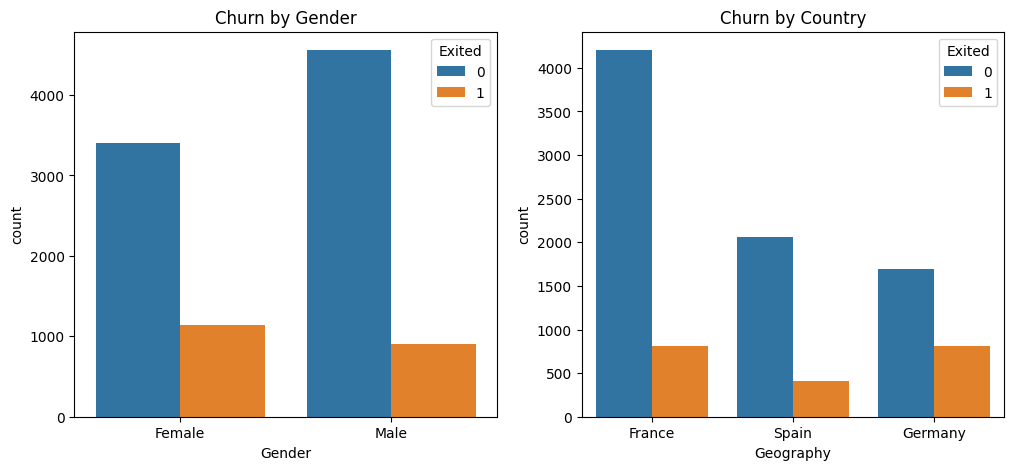

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(data=df, x='Gender', hue='Exited')
plt.title("Churn by Gender")

plt.subplot(1,2,2)
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title("Churn by Country")
plt.show()

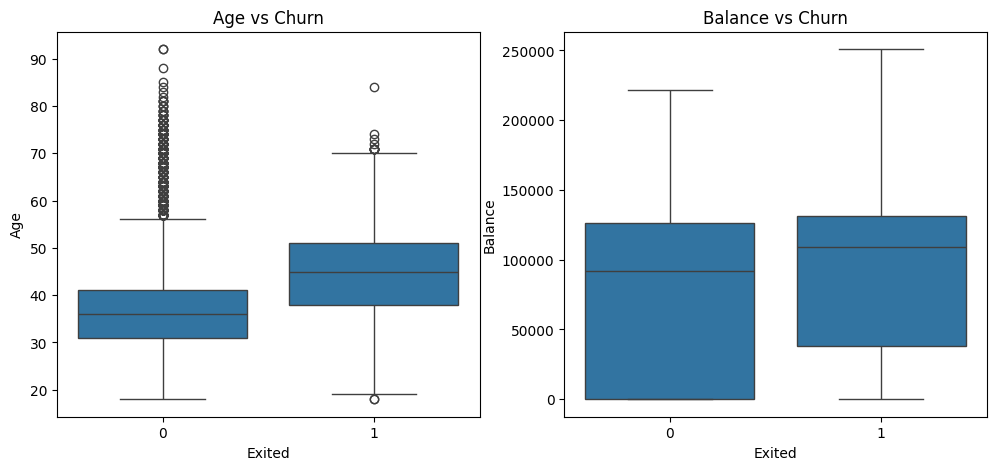

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x='Exited', y='Age')
plt.title("Age vs Churn")

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Exited', y='Balance')
plt.title("Balance vs Churn")
plt.show()

# Section 4: Data Cleaning + Feature Engineering

In [6]:
# Drop useless columns
df = df.drop(columns=['RowNumber', 'Surname'])

print("Columns after dropping:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

Columns after dropping: ['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing Values:
 CustomerId         0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
# Encode categorical variables
df = pd.get_dummies(df, columns=['Gender', 'Geography'], drop_first=True)

print("Columns after encoding:")
print(df.columns.tolist())
display(df.head())

Columns after encoding:
['CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Gender_Male', 'Geography_Germany', 'Geography_Spain']


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [8]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10000, 12)
Target shape: (10000,)


# Section 5: Train-Test Split + Feature Scaling

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Feature scaling completed!")

Training set: (8000, 12)
Test set: (2000, 12)

✅ Feature scaling completed!


# Section 6: Model Training + MLflow (Final Clean Version)

In [10]:
with mlflow.start_run(run_name="RandomForest_Baseline"):

    # Train Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Log to MLflow
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(model, "random_forest_model")

    print("✅ Model trained and logged successfully to MLflow!")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1 Score: {f1:.4f}")

2026/06/03 09:52:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 09:52:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Model trained and logged successfully to MLflow!
Accuracy: 0.8635 | Precision: 0.7479 | Recall: 0.4606 | F1 Score: 0.5701


In [11]:
import mlflow
import os
from mlflow.tracking import MlflowClient

# Set tracking URI correctly
project_root = os.path.dirname(os.getcwd())
mlruns_path = os.path.join(project_root, "mlruns")
mlflow.set_tracking_uri(f"file:{mlruns_path}")
mlflow.set_experiment("ChurnGuard_Baseline")

print("Tracking URI:", mlflow.get_tracking_uri())

# Create a simple test run
with mlflow.start_run(run_name="Test_Run"):
    mlflow.log_param("test_param", "hello")
    mlflow.log_metric("test_metric", 99.99)
    print("✅ Test run created successfully!")

# Check experiments and runs
client = MlflowClient()
exp = client.get_experiment_by_name("ChurnGuard_Baseline")
print(f"\nExperiment ID: {exp.experiment_id}")

runs = client.search_runs(exp.experiment_id)
print(f"Total runs in ChurnGuard_Baseline: {len(runs)}")

for run in runs:
    print(f"  - Run Name: {run.info.run_name}, Run ID: {run.info.run_id}")

Tracking URI: file:/Users/amritanshudash/Desktop/ChurnGuard/mlruns
✅ Test run created successfully!

Experiment ID: 506424314219050395
Total runs in ChurnGuard_Baseline: 5
  - Run Name: Test_Run, Run ID: 90c300e6999c48d6b96b5a79bd4f20c4
  - Run Name: RandomForest_Baseline, Run ID: b85dd88e8c6f44e196327b16543d55c3
  - Run Name: Test_Run, Run ID: 3d4f72cea2c649a5b430fde677478f51
  - Run Name: RandomForest_Baseline, Run ID: 15dff46dd54e43f4b0993f5165c60ad1
  - Run Name: RandomForest_Baseline, Run ID: a54c902629274bbfb67d8cd48b3f7414
